In [62]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


PENGUMPULAN DATA

In [63]:
import pandas as pd

file_path = '/content/drive/MyDrive/semhas kode/data radiosonde 19-25_gabung.xlsx'

df = pd.read_excel(file_path)
df

,Tanggal,850 00.00,850 12.00,700 00.00,700 12.00,500 00.00,500 12.00,SWEAT 00.00,SWEAT 12.00,LCL 00.00,...,CIN 12.00,MVV 00.00,MVV 12.00,CH,Height,Press0,Temp0,Humi0,WS,WD
0,2019-01-01,81.0,81.0,85.0,72,38,55.0,"227,2","227,5",403,...,-24,41,55,0,11244.485765,338.183767,-35.773167,55.322895,10.856032,168.551528
1,2019-01-02,81.0,93.0,83.0,92,86,94.0,"206,1","237,3",503,...,-42,41,35,0,11297.744256,342.363058,-32.865369,59.159663,9.107495,136.160639
2,2019-01-03,93.0,83.0,96.0,89,100,98.0,"221,7","223,8",194,...,-21,39,44,"6,8",12206.825097,310.191993,-39.077880,62.002273,10.937249,157.966931
3,2019-01-04,87.0,77.0,83.0,70,94,72.0,"198,4","223,4",168,...,0,33,70,"38,5",10883.828545,358.674046,-32.074478,60.591993,10.877018,202.220133
4,2019-01-05,85.0,71.0,65.0,65,81,80.0,"220,2","193,1",168,...,-22,42,64,1,8312.081650,478.850790,-17.090369,56.927706,8.760821,248.055407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2552,2025-12-26,NaN,NaN,NaN,NaN,NaN,NaN,205.2,0,404,...,NaN,NaN,NaN,10,14481.718041,263.328067,-40.439256,26.346737,10.972894,116.846707
2553,2025-12-27,NaN,NaN,NaN,NaN,NaN,NaN,188.5,232.9,155,...,NaN,NaN,NaN,10,13922.148288,274.356514,-39.774634,24.766886,11.362708,120.151344
2554,2025-12-28,NaN,NaN,NaN,NaN,NaN,NaN,183.6,242.5,430,...,NaN,NaN,NaN,0,14667.578171,262.856572,-39.740295,21.007110,11.518194,119.120793
2555,2025-12-29,NaN,NaN,NaN,NaN,NaN,NaN,219.9,220.8,185,...,NaN,NaN,NaN,0,13627.366019,278.848591,-39.567432,22.379381,11.409273,111.423511


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PREPROCESSING

In [64]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace('.', '', regex=False)

In [65]:
# konversi data
df = df.replace(',', '.', regex=True)
exclude_cols = ['Tanggal']
for col in df.columns:
    if col not in exclude_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['Tanggal'] = pd.to_datetime(df['Tanggal'])

In [6]:
df

,Tanggal,850_0000,850_1200,700_0000,700_1200,500_0000,500_1200,SWEAT_0000,SWEAT_1200,LCL_0000,...,CIN_1200,MVV_0000,MVV_1200,CH,Height,Press0,Temp0,Humi0,WS,WD
0,2019-01-01,81.0,81.0,85.0,72.0,38.0,55.0,227.2,227.5,403.0,...,-24.0,41.0,55.0,0.0,11244.485765,338.183767,-35.773167,55.322895,10.856032,168.551528
1,2019-01-02,81.0,93.0,83.0,92.0,86.0,94.0,206.1,237.3,503.0,...,-42.0,41.0,35.0,0.0,11297.744256,342.363058,-32.865369,59.159663,9.107495,136.160639
2,2019-01-03,93.0,83.0,96.0,89.0,100.0,98.0,221.7,223.8,194.0,...,-21.0,39.0,44.0,6.8,12206.825097,310.191993,-39.077880,62.002273,10.937249,157.966931
3,2019-01-04,87.0,77.0,83.0,70.0,94.0,72.0,198.4,223.4,168.0,...,0.0,33.0,70.0,38.5,10883.828545,358.674046,-32.074478,60.591993,10.877018,202.220133
4,2019-01-05,85.0,71.0,65.0,65.0,81.0,80.0,220.2,193.1,168.0,...,-22.0,42.0,64.0,1.0,8312.081650,478.850790,-17.090369,56.927706,8.760821,248.055407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2552,2025-12-26,NaN,NaN,NaN,NaN,NaN,NaN,205.2,0.0,404.0,...,NaN,NaN,NaN,10.0,14481.718041,263.328067,-40.439256,26.346737,10.972894,116.846707
2553,2025-12-27,NaN,NaN,NaN,NaN,NaN,NaN,188.5,232.9,155.0,...,NaN,NaN,NaN,10.0,13922.148288,274.356514,-39.774634,24.766886,11.362708,120.151344
2554,2025-12-28,NaN,NaN,NaN,NaN,NaN,NaN,183.6,242.5,430.0,...,NaN,NaN,NaN,0.0,14667.578171,262.856572,-39.740295,21.007110,11.518194,119.120793
2555,2025-12-29,NaN,NaN,NaN,NaN,NaN,NaN,219.9,220.8,185.0,...,NaN,NaN,NaN,0.0,13627.366019,278.848591,-39.567432,22.379381,11.409273,111.423511


In [7]:
# Cek missing value
df.isnull().sum()

,0
Tanggal,0
850_0000,375
850_1200,912
700_0000,375
700_1200,912
500_0000,376
500_1200,912
SWEAT_0000,49
SWEAT_1200,707
LCL_0000,47


In [66]:
# missing value
df = df.interpolate(method='linear')
df

,Tanggal,850_0000,850_1200,700_0000,700_1200,500_0000,500_1200,SWEAT_0000,SWEAT_1200,LCL_0000,...,CIN_1200,MVV_0000,MVV_1200,CH,Height,Press0,Temp0,Humi0,WS,WD
0,2019-01-01,81.0,81.0,85.0,72.0,38.0,55.0,227.2,227.5,403.0,...,-24.0,41.0,55.0,0.0,11244.485765,338.183767,-35.773167,55.322895,10.856032,168.551528
1,2019-01-02,81.0,93.0,83.0,92.0,86.0,94.0,206.1,237.3,503.0,...,-42.0,41.0,35.0,0.0,11297.744256,342.363058,-32.865369,59.159663,9.107495,136.160639
2,2019-01-03,93.0,83.0,96.0,89.0,100.0,98.0,221.7,223.8,194.0,...,-21.0,39.0,44.0,6.8,12206.825097,310.191993,-39.077880,62.002273,10.937249,157.966931
3,2019-01-04,87.0,77.0,83.0,70.0,94.0,72.0,198.4,223.4,168.0,...,0.0,33.0,70.0,38.5,10883.828545,358.674046,-32.074478,60.591993,10.877018,202.220133
4,2019-01-05,85.0,71.0,65.0,65.0,81.0,80.0,220.2,193.1,168.0,...,-22.0,42.0,64.0,1.0,8312.081650,478.850790,-17.090369,56.927706,8.760821,248.055407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2552,2025-12-26,85.0,87.0,72.0,80.0,81.0,89.0,205.2,0.0,404.0,...,-16.0,14.0,57.5,10.0,14481.718041,263.328067,-40.439256,26.346737,10.972894,116.846707
2553,2025-12-27,85.0,87.0,72.0,80.0,81.0,89.0,188.5,232.9,155.0,...,-16.0,14.0,57.5,10.0,13922.148288,274.356514,-39.774634,24.766886,11.362708,120.151344
2554,2025-12-28,85.0,87.0,72.0,80.0,81.0,89.0,183.6,242.5,430.0,...,-16.0,14.0,57.5,0.0,14667.578171,262.856572,-39.740295,21.007110,11.518194,119.120793
2555,2025-12-29,85.0,87.0,72.0,80.0,81.0,89.0,219.9,220.8,185.0,...,-16.0,14.0,57.5,0.0,13627.366019,278.848591,-39.567432,22.379381,11.409273,111.423511


In [9]:
df.isnull().sum()

,0
Tanggal,0
850_0000,0
850_1200,0
700_0000,0
700_1200,0
500_0000,0
500_1200,0
SWEAT_0000,0
SWEAT_1200,0
LCL_0000,0


In [67]:
# rata-rata
df['850_avg'] = (df['850_0000'] + df['850_1200']) / 2
df['700_avg'] = (df['700_0000'] + df['700_1200']) / 2
df['500_avg'] = (df['500_0000'] + df['500_1200']) / 2

df['SWEAT_avg'] = (df['SWEAT_0000'] + df['SWEAT_1200']) / 2

df['LCL_avg'] = (df['LCL_0000'] + df['LCL_1200']) / 2
df['CCL_avg'] = (df['CCL_0000'] + df['CCL_1200']) / 2
df['LFC_avg'] = (df['LFC_0000'] + df['LFC_1200']) / 2

df['LI_avg'] = (df['LI_0000'] + df['LI_1200']) / 2
df['KI_avg'] = (df['KI_0000'] + df['KI_1200']) / 2

df['CAPE_avg'] = (df['CAPE_0000'] + df['CAPE_1200']) / 2

df['SI_avg'] = (df['SI_0000'] + df['SI_1200']) / 2

df['TT_avg'] = (df['TT_0000'] + df['TT_1200']) / 2

df['KO_avg'] = (df['KO_0000'] + df['KO_1200']) / 2

df['TPW_avg'] = (df['TPW_0000'] + df['TPW_1200']) / 2

df['BOYDEN_avg'] = (df['BOYDEN_0000'] + df['BOYDEN_1200']) / 2

df['CIN_avg'] = (df['CIN_0000'] + df['CIN_1200']) / 2

df['MVV_avg'] = (df['MVV_0000'] + df['MVV_1200']) / 2

In [68]:
df = df[
    ['Tanggal', 'CH', 'Height', 'Press0', 'Temp0', 'Humi0', 'WS', 'WD']
    + [col for col in df.columns if col.endswith('_avg')]
]

# Hapus suffix "_avg"
df.rename(columns=lambda x: x.replace('_avg', ''), inplace=True)

df

/tmp/ipykernel_1640/3907718637.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns=lambda x: x.replace('_avg', ''), inplace=True)


,Tanggal,CH,Height,Press0,Temp0,Humi0,WS,WD,850,700,...,LI,KI,CAPE,SI,TT,KO,TPW,BOYDEN,CIN,MVV
0,2019-01-01,0.0,11244.485765,338.183767,-35.773167,55.322895,10.856032,168.551528,81.0,78.5,...,-2.50,18.25,1183.0,0.00,43.10,-5.00,5745.0,96.45,-50.5,48.00
1,2019-01-02,0.0,11297.744256,342.363058,-32.865369,59.159663,9.107495,136.160639,87.0,87.5,...,-2.50,36.55,731.0,0.00,43.50,-3.60,6095.0,96.15,-42.5,38.00
2,2019-01-03,6.8,12206.825097,310.191993,-39.077880,62.002273,10.937249,157.966931,88.0,92.5,...,-2.50,18.50,858.5,0.00,42.70,-1.35,6185.0,96.35,-37.0,41.50
3,2019-01-04,38.5,10883.828545,358.674046,-32.074478,60.591993,10.877018,202.220133,82.0,76.5,...,-3.75,33.20,1513.5,0.00,42.25,-6.95,5575.0,95.80,-23.5,51.50
4,2019-01-05,1.0,8312.081650,478.850790,-17.090369,56.927706,8.760821,248.055407,78.0,65.0,...,-4.95,31.95,1462.0,0.00,43.50,-9.50,5485.0,95.90,-21.5,53.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2552,2025-12-26,10.0,14481.718041,263.328067,-40.439256,26.346737,10.972894,116.846707,86.0,76.0,...,-1.50,17.05,544.5,0.00,22.10,-4.45,6371.5,95.65,-107.5,35.75
2553,2025-12-27,10.0,13922.148288,274.356514,-39.774634,24.766886,11.362708,120.151344,86.0,76.0,...,-2.50,32.75,664.5,-0.45,44.30,-11.05,6371.5,95.65,-107.5,35.75
2554,2025-12-28,0.0,14667.578171,262.856572,-39.740295,21.007110,11.518194,119.120793,86.0,76.0,...,-3.50,35.25,1915.0,0.25,43.00,-11.05,6371.5,95.65,-107.5,35.75
2555,2025-12-29,0.0,13627.366019,278.848591,-39.567432,22.379381,11.409273,111.423511,86.0,76.0,...,-3.00,30.55,1527.5,-0.55,43.25,-13.65,6371.5,95.65,-107.5,35.75


In [3]:
import pandas as pd

file_path = '/content/drive/MyDrive/semhas kode/dataset_bersih.xlsx'

df = pd.read_excel(file_path)
df

,Tanggal,CH,Height,Press0,Temp0,Humi0,WS,WD,850,700,...,LI,KI,CAPE,SI,TT,KO,TPW,BOYDEN,CIN,MVV
0,2019-01-01,0.0,11244.485765,338.183767,-35.773167,55.322895,10.856032,168.551528,81.0,78.5,...,-2.50,18.25,1183.0,0.00,43.10,-5.00,5745.0,96.45,-50.5,48.00
1,2019-01-02,0.0,11297.744256,342.363058,-32.865369,59.159663,9.107495,136.160639,87.0,87.5,...,-2.50,36.55,731.0,0.00,43.50,-3.60,6095.0,96.15,-42.5,38.00
2,2019-01-03,6.8,12206.825097,310.191993,-39.077880,62.002273,10.937249,157.966931,88.0,92.5,...,-2.50,18.50,858.5,0.00,42.70,-1.35,6185.0,96.35,-37.0,41.50
3,2019-01-04,38.5,10883.828545,358.674046,-32.074478,60.591993,10.877018,202.220133,82.0,76.5,...,-3.75,33.20,1513.5,0.00,42.25,-6.95,5575.0,95.80,-23.5,51.50
4,2019-01-05,1.0,8312.081650,478.850790,-17.090369,56.927706,8.760821,248.055407,78.0,65.0,...,-4.95,31.95,1462.0,0.00,43.50,-9.50,5485.0,95.90,-21.5,53.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2552,2025-12-26,10.0,14481.718041,263.328067,-40.439256,26.346737,10.972894,116.846707,86.0,76.0,...,-1.50,17.05,544.5,0.00,22.10,-4.45,6371.5,95.65,-107.5,35.75
2553,2025-12-27,10.0,13922.148288,274.356514,-39.774634,24.766886,11.362708,120.151344,86.0,76.0,...,-2.50,32.75,664.5,-0.45,44.30,-11.05,6371.5,95.65,-107.5,35.75
2554,2025-12-28,0.0,14667.578171,262.856572,-39.740295,21.007110,11.518194,119.120793,86.0,76.0,...,-3.50,35.25,1915.0,0.25,43.00,-11.05,6371.5,95.65,-107.5,35.75
2555,2025-12-29,0.0,13627.366019,278.848591,-39.567432,22.379381,11.409273,111.423511,86.0,76.0,...,-3.00,30.55,1527.5,-0.55,43.25,-13.65,6371.5,95.65,-107.5,35.75


EDA

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2557 entries, 0 to 2556
Data columns (total 25 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Tanggal  2557 non-null   datetime64[ns]
 1   CH       2557 non-null   float64       
 2   Height   2557 non-null   float64       
 3   Press0   2557 non-null   float64       
 4   Temp0    2557 non-null   float64       
 5   Humi0    2557 non-null   float64       
 6   WS       2557 non-null   float64       
 7   WD       2557 non-null   float64       
 8   850      2557 non-null   float64       
 9   700      2557 non-null   float64       
 10  500      2557 non-null   float64       
 11  SWEAT    2557 non-null   float64       
 12  LCL      2557 non-null   float64       
 13  CCL      2557 non-null   float64       
 14  LFC      2557 non-null   float64       
 15  LI       2557 non-null   float64       
 16  KI       2557 non-null   float64       
 17  CAPE     2557 non-null   float64 

In [14]:
# statistik deskriptif
df.describe()

,Tanggal,CH,Height,Press0,Temp0,Humi0,WS,WD,850,700,...,LI,KI,CAPE,SI,TT,KO,TPW,BOYDEN,CIN,MVV
count,2557,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,...,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000
mean,2022-07-01 15:55:40.946421504,6.992726,12958.015336,305.266249,-36.711479,37.104999,9.784528,144.385397,78.402327,64.431228,...,-2.518762,28.999431,1205.626985,0.873973,41.431864,-11.173602,5392.522898,95.979556,-78.449374,35.728158
min,2019-01-01 00:00:00,0.000000,321.886897,138.115257,-48.191014,10.343579,2.920282,68.241649,19.000000,1.000000,...,-24.500000,-29.400000,-15.000000,-15.500000,0.400000,-46.083562,1631.500000,47.100000,-581.669492,-191.000000
25%,2020-10-01 00:00:00,0.000000,12187.717440,271.165948,-39.827102,25.691211,8.023982,120.061519,73.364407,53.000000,...,-3.800000,25.050000,645.758389,-0.150000,40.400000,-14.050000,4766.050847,95.650000,-107.500000,20.777108
50%,2022-07-02 00:00:00,0.000000,13530.225566,285.180306,-38.958829,34.390017,9.657636,140.456067,81.500000,72.500000,...,-2.957627,32.436747,1119.000000,0.174575,42.400000,-10.965068,5675.000000,96.250000,-67.000000,35.000000
75%,2024-03-31 00:00:00,4.200000,14161.543290,315.009015,-37.199328,46.369795,11.409273,163.629434,86.000000,78.000000,...,-1.500000,35.455763,1688.123729,1.450000,43.700000,-8.266438,6241.000000,96.750000,-33.855932,47.000000
max,2025-12-30 00:00:00,156.600000,15642.447141,972.642069,26.382759,99.591781,18.451425,330.280000,100.000000,98.500000,...,12.450000,190.500000,19716.000000,17.850000,48.900000,61.550000,29803.072289,101.200000,90.374172,1678.750000
std,NaN,16.273606,1776.220452,61.796169,6.810665,14.146464,2.426393,31.978177,11.448702,20.845469,...,2.033715,11.076672,883.003586,2.008035,3.977567,5.160276,1124.469559,2.589343,60.793453,46.074063


In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Jumlah subplot
n = len(df)
n_cols = 4
n_rows = int(np.ceil(n / n_cols))

# Buat figure
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 3 * n_rows),
    sharex=True
)

# Ubah axes menjadi 1 dimensi
axes = np.array(axes).flatten()

# Plot masing-masing variabel
for i, kolom in enumerate(df):
    axes[i].plot(
        df["Tanggal"],
        df[kolom],
        linewidth=0.7
    )

    axes[i].set_title(kolom, fontsize=11)
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis="x", rotation=30)

# Hapus subplot kosong
for i in range(len(df), len(axes)):
    fig.delaxes(axes[i])

fig.suptitle(
    "Visualisasi Variabel Meteorologi",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7dc96248a840> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7dc962473d80> (for post_execute):


KeyboardInterrupt: 

/tmp/ipykernel_1640/1576296216.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Bulan"] = df["Tanggal"].dt.month


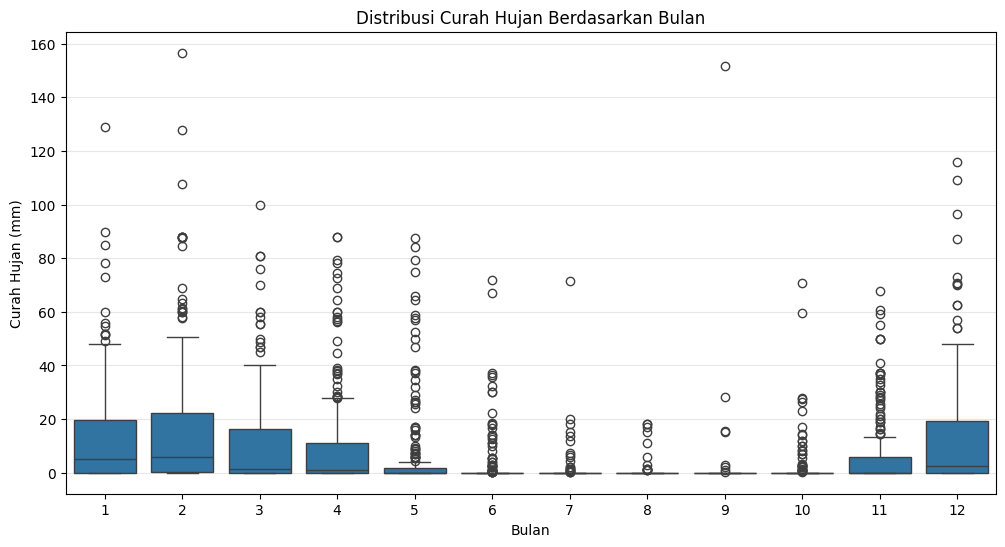

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

df["Bulan"] = df["Tanggal"].dt.month
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="Bulan",
    y="CH"
)

plt.title("Distribusi Curah Hujan Berdasarkan Bulan")
plt.xlabel("Bulan")
plt.ylabel("Curah Hujan (mm)")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [1]:
pip install pytorch_tabnet

In [2]:
pip install optuna

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

from pytorch_tabnet.tab_model import TabNetRegressor

from statsmodels.tsa.stattools import ccf

from xgboost import XGBRegressor

import optuna

In [ ]:
# Pastikan tanggal bertipe datetime
df["Tanggal"] = pd.to_datetime(df["Tanggal"])

# Urutkan berdasarkan waktu
df = df.sort_values(
    "Tanggal"
).reset_index(drop=True)

NameError: name 'df' is not defined

MENENTUKAN TARGET DAN FITUR AWAL

In [ ]:
target = "CH"

features_awal = [
    col for col in df.columns
    if col not in ["Tanggal", target]
]

print("\nJumlah fitur awal :", len(features_awal))
print(features_awal)


CHRONOLOGICAL TRAIN-TEST SPLIT

In [ ]:
train_mask = df["Tanggal"].dt.year <= 2024
test_mask = df["Tanggal"].dt.year == 2025

df_train = df.loc[
    train_mask
].copy()

df_test = df.loc[
    test_mask
].copy()

In [ ]:
print("\nTRAINING")
print("Periode :",
      df_train["Tanggal"].min(),
      "sampai",
      df_train["Tanggal"].max())

print("Jumlah :", len(df_train))

print("\nTESTING")
print("Periode :",
      df_test["Tanggal"].min(),
      "sampai",
      df_test["Tanggal"].max())

print("Jumlah :", len(df_test))

PEARSON CORRELATION SCREENING

In [ ]:
pearson_result = []

for feature in features_awal:

    r = df_train[feature].corr(
        df_train[target],
        method="pearson"
    )

    pearson_result.append({
        "Feature": feature,
        "Pearson_r": r,
        "Abs_r": abs(r)
    })


pearson_df = pd.DataFrame(
    pearson_result
)

pearson_df = pearson_df.sort_values(
    "Abs_r",
    ascending=False
).reset_index(drop=True)


# Threshold Pearson
pearson_threshold = 0.07

features_pearson = pearson_df.loc[
    pearson_df["Abs_r"] >= pearson_threshold,
    "Feature"
].tolist()

In [ ]:
print(
    "\nJumlah fitur awal :",
    len(features_awal)
)

print(
    "Threshold |r| >= ",
    pearson_threshold
)

print(
    "Jumlah fitur setelah Pearson :",
    len(features_pearson)
)

display(pearson_df)


DATA TABNET

In [ ]:
X_train_tabnet = df_train[
    features_pearson
].copy()

y_train_tabnet = df_train[
    target
].copy()

In [ ]:
scaler_tabnet = StandardScaler()

X_scaled = scaler_tabnet.fit_transform(
    X_train_tabnet
)


TABNET FEATURE SELECTION

In [ ]:
# 90% untuk training, 10% untuk validation
split_val = int(len(X_train_tabnet) * 0.9)

X_tr = X_train_tabnet.iloc[:split_val]
X_val = X_train_tabnet.iloc[split_val:]

y_tr = y_train_tabnet.iloc[:split_val]
y_val = y_train_tabnet.iloc[split_val:]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_tr_scaled = scaler.fit_transform(X_tr)
X_val_scaled = scaler.transform(X_val)

In [ ]:
for fitur in ["Humi0", "LCL", "700"]:
    i = X_tr.columns.get_loc(fitur)

    print(f"\n{fitur}")
    print("Mean :", scaler.mean_[i])
    print("Std  :", scaler.scale_[i])

In [ ]:
tabnet = TabNetRegressor(
    n_d=32,
    n_a=32,
    n_steps=7,
    gamma=1.8,
    lambda_sparse=1e-7,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.005),
    seed=42,
    verbose=1
)

tabnet.fit(
    X_train=X_tr_scaled,
    y_train=y_tr.values.reshape(-1, 1),

    eval_set=[
        (X_tr_scaled, y_tr.values.reshape(-1, 1)),
        (X_val_scaled, y_val.values.reshape(-1, 1))
    ],

    eval_name=["train", "valid"],
    eval_metric=["rmse"],

    max_epochs=100,
    patience=50,
    batch_size=64,
    virtual_batch_size=32
)

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(tabnet.history["train_rmse"]) + 1),
    tabnet.history["train_rmse"],
    label="Training RMSE",
    linewidth=1.5
)

plt.plot(
    range(1, len(tabnet.history["valid_rmse"]) + 1),
    tabnet.history["valid_rmse"],
    label="Validation RMSE",
    linewidth=1.5
)

plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Training dan Validation RMSE TabNet")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
# 5 data yang digunakan
X_manual = X_scaled[:5]
y_manual = y_train_tabnet.iloc[:5].values

# Prediksi TabNet
pred_manual = tabnet.predict(X_manual).flatten()

print("X setelah standardisasi:")
print(X_manual)

print("\nY aktual:")
print(y_manual)

print("\nY prediksi:")
print(pred_manual)

print("\nFeature importance:")
print(tabnet.feature_importances_)

X setelah standardisasi:
[[ 1.24575204  0.59143222  0.72919257 -0.29880905  0.45325483  0.32397341
  -0.95295851  0.29019817  0.42147433 -0.46510013 -0.00757306 -0.89761364
   0.33238878  0.35955501  0.46685601 -0.04758822 -0.3517634   1.45320016
   0.08870238]
 [ 1.50950243 -0.57546828  1.13980379  1.30254519  0.76162138  0.82824914
   0.77870213 -0.18021843  0.51977774 -0.46510013 -0.00757306 -0.86827726
   0.25031162  0.48384533  0.53246706 -0.54648951 -0.52781828  1.77538763
   0.50226823]
 [ 1.70491155 -1.17551558  1.36792113  1.63385986  0.84091564  0.9122951
  -0.92930194 -0.37315427  0.32317093 -0.46510013 -0.00757306 -0.36752825
   0.2655649   0.56929492  0.02741067 -0.40575961 -0.99562122  2.29318891
  -0.38131528]
 [ 1.60796488 -0.30480864  0.63794564  1.044856    0.3034768   0.40801937
   0.46170414 -0.27560244  0.2125796  -0.46510013 -0.60140089 -1.09627446
   0.09342078  0.77903484  0.7885347   0.31720575 -0.86169376  1.00443904
   0.61475379]
 [ 1.35607135  0.57611186  0

In [33]:
masks = tabnet.explain(X_manual)

print("Feature mask:")
print(masks[0])

Feature mask:
[[16.60564232  0.          0.          0.          3.56043506  0.
  24.78367424  0.          0.          3.79411888  0.          3.34921288
   1.24687457  0.          4.16295242  1.44945645  0.70595402  1.19967318
   0.49814692]
 [ 0.          4.65341568  7.16302633  6.00792503  0.          1.50795364
   5.93752956  0.          0.          0.          0.          7.96502066
   0.          0.          0.          0.          7.93115425  0.
   0.        ]
 [ 1.4776516   0.          0.          0.          4.79329395  0.1086368
   1.24676657  0.          0.          0.53015697  1.46844649  2.78471899
   0.          0.          1.73647237  1.593925   28.89113617 23.63717461
   1.16529536]
 [21.39697647  0.          0.          0.          1.8879596   2.50204372
   0.95566255  0.          0.1541969   2.13108706  0.          0.
   0.          0.          5.69569111  2.48606563  0.20932576  0.38075784
   1.63743186]
 [18.06554222  0.          0.81292021  0.          1.41328967  

FEATURE IMPORTANCE TABNET

In [34]:
importance = tabnet.feature_importances_


feature_importance = pd.DataFrame({
    "Feature": features_pearson,
    "Importance": importance
})


feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)


In [35]:
N_FEATURES = 15

selected_features = feature_importance.head(
    N_FEATURES
)["Feature"].tolist()
display(
    feature_importance.head(15)
)

,Feature,Importance
0,Humi0,0.102362
1,700,0.095957
2,LFC,0.092347
3,CAPE,0.072812
4,Height,0.072004
5,TPW,0.066853
6,KI,0.061317
7,SI,0.058634
8,500,0.054723
9,TT,0.054402


PENENTUAN LAG DENGAN CCF
CCF digunakan untuk melihat hubungan antara:
X(t-lag) -> CH(t)
CCF dilakukan hanya pada DATA TRAINING.
MAX_LAG = 7 hari
Lag setiap fitur dapat berbeda.

In [36]:
MAX_LAG = 7

lag_results = []


for feature in selected_features:

    x = df_train[feature].values
    y = df_train[target].values

    # Hilangkan kemungkinan NaN
    valid = (
        np.isfinite(x)
        &
        np.isfinite(y)
    )

    x = x[valid]
    y = y[valid]

    # CCF
    ccf_values = ccf(
        x,
        y,
        adjusted=False
    )

    # Kandidat lag 1-7
    candidate_ccf = ccf_values[
        1:MAX_LAG + 1
    ]
     # Lag dengan absolut CCF terbesar
    best_idx = np.argmax(
        np.abs(candidate_ccf)
    )

    best_lag = best_idx + 1

    best_ccf = candidate_ccf[
        best_idx
    ]

    lag_results.append({
        "Feature": feature,
        "Lag": best_lag,
        "CCF": best_ccf,
        "Abs_CCF": abs(best_ccf)
    })


lag_df = pd.DataFrame(
    lag_results
)

lag_df = lag_df.sort_values(
    "Abs_CCF",
    ascending=False
).reset_index(drop=True)
display(lag_df)

,Feature,Lag,CCF,Abs_CCF
0,Humi0,1,0.322576,0.322576
1,TPW,1,0.264984,0.264984
2,700,1,0.262956,0.262956
3,LCL,1,-0.257148,0.257148
4,500,1,0.248329,0.248329
5,KI,1,0.220101,0.220101
6,850,4,0.210695,0.210695
7,LI,1,-0.175745,0.175745
8,SI,1,-0.166341,0.166341
9,TT,3,0.159531,0.159531


In [37]:
selected_lags = dict(
    zip(
        lag_df["Feature"],
        lag_df["Lag"]
    )
)

print("\nLag yang digunakan:")

for feature, lag in selected_lags.items():

    print(
        f"{feature} -> lag {lag}"
    )


Lag yang digunakan:
Humi0 -> lag 1
TPW -> lag 1
700 -> lag 1
LCL -> lag 1
500 -> lag 1
KI -> lag 1
850 -> lag 4
LI -> lag 1
SI -> lag 1
TT -> lag 3
CAPE -> lag 3
Height -> lag 1
LFC -> lag 1
Press0 -> lag 7
Temp0 -> lag 7


MEMBENTUK DATA LAG
membentuk lag berdasarkan fitur yang sudah dipilih oleh TabNet.
Setiap fitur menggunakan lag hasil CCF masing-masing.

In [38]:
df_model = df[
    ["Tanggal", target] + selected_features
].copy()

df_model = df_model.sort_values(
    "Tanggal"
).reset_index(drop=True)


for feature, lag in selected_lags.items():

    df_model[
        f"{feature}_lag{lag}"
    ] = df_model[
        feature
    ].shift(lag)



In [39]:
CH_LAG = 1

df_model[
    f"CH_lag{CH_LAG}"
] = df_model[
    "CH"
].shift(CH_LAG)

 FITUR MUSIMAN

In [40]:
df_model["month"] = (
    df_model["Tanggal"].dt.month
)

df_model["month_sin"] = np.sin(
    2 * np.pi *
    df_model["month"] / 12
)

df_model["month_cos"] = np.cos(
    2 * np.pi *
    df_model["month"] / 12
)


MENGHAPUS BARIS AKIBAT LAG

In [41]:
df_model = df_model.dropna(
    subset=[
        f"{feature}_lag{lag}"
        for feature, lag
        in selected_lags.items()
    ]
    +
    [f"CH_lag{CH_LAG}"]
).reset_index(drop=True)


print(df_model.shape)

(2550, 36)


In [42]:
df_model

,Tanggal,CH,Humi0,700,LFC,CAPE,Height,TPW,KI,SI,...,TT_lag3,CAPE_lag3,Height_lag1,LFC_lag1,Press0_lag7,Temp0_lag7,CH_lag1,month,month_sin,month_cos
0,2019-01-08,6.4,30.210083,65.5,1304.5,1653.5,12199.843207,5400.0,34.30,0.00,...,43.50,1462.0,8715.312832,1867.5,338.183767,-35.773167,0.0,1,5.000000e-01,0.866025
1,2019-01-09,0.0,32.686168,51.5,1119.0,2436.5,13079.497675,5055.0,27.90,0.00,...,43.10,1641.5,12199.843207,1304.5,342.363058,-32.865369,6.4,1,5.000000e-01,0.866025
2,2019-01-10,0.0,54.263664,52.0,1087.5,1949.0,11633.080787,5685.0,32.40,0.00,...,44.35,1109.0,13079.497675,1119.0,310.191993,-39.077880,0.0,1,5.000000e-01,0.866025
3,2019-01-11,0.5,41.852026,70.5,2466.0,576.0,11884.069487,5485.0,34.45,0.00,...,46.20,1653.5,11633.080787,1087.5,358.674046,-32.074478,0.0,1,5.000000e-01,0.866025
4,2019-01-12,2.0,42.715199,48.5,1687.5,1014.0,12734.208882,5360.0,27.60,0.00,...,42.80,2436.5,11884.069487,2466.0,478.850790,-17.090369,0.5,1,5.000000e-01,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2545,2025-12-26,10.0,26.346737,76.0,881.5,544.5,14481.718041,6371.5,17.05,0.00,...,43.15,1551.5,14796.762533,1186.0,267.332154,-39.322015,35.0,12,-2.449294e-16,1.000000
2546,2025-12-27,10.0,24.766886,76.0,2828.5,664.5,13922.148288,6371.5,32.75,-0.45,...,45.05,1431.0,14481.718041,881.5,288.810663,-38.897269,10.0,12,-2.449294e-16,1.000000
2547,2025-12-28,0.0,21.007110,76.0,1442.0,1915.0,14667.578171,6371.5,35.25,0.25,...,44.35,1867.0,13922.148288,2828.5,265.720775,-39.426488,10.0,12,-2.449294e-16,1.000000
2548,2025-12-29,0.0,22.379381,76.0,1574.5,1527.5,13627.366019,6371.5,30.55,-0.55,...,22.10,544.5,14667.578171,1442.0,279.191697,-38.785340,0.0,12,-2.449294e-16,1.000000


MENENTUKAN FITUR XGBOOST

In [43]:
lag_features = [
    f"{feature}_lag{lag}"
    for feature, lag
    in selected_lags.items()
]


xgb_features = (
    lag_features
    +
    [f"CH_lag{CH_LAG}"]
    +
    [
        "month",
        "month_sin",
        "month_cos"
    ]
)


print("\nJumlah fitur XGBoost:",
      len(xgb_features))

print("\nFitur XGBoost:")
print(xgb_features)


Jumlah fitur XGBoost: 19

Fitur XGBoost:
['Humi0_lag1', 'TPW_lag1', '700_lag1', 'LCL_lag1', '500_lag1', 'KI_lag1', '850_lag4', 'LI_lag1', 'SI_lag1', 'TT_lag3', 'CAPE_lag3', 'Height_lag1', 'LFC_lag1', 'Press0_lag7', 'Temp0_lag7', 'CH_lag1', 'month', 'month_sin', 'month_cos']


MEMISAHKAN TRAINING DAN TESTING

In [44]:

train_model = df_model[
    df_model["Tanggal"].dt.year <= 2024
].copy()

test_model = df_model[
    df_model["Tanggal"].dt.year == 2025
].copy()

print(
    "Training :",
    train_model["Tanggal"].min(),
    "sampai",
    train_model["Tanggal"].max(),
    "| n =",
    len(train_model)
)

print(
    "Testing  :",
    test_model["Tanggal"].min(),
    "sampai",
    test_model["Tanggal"].max(),
    "| n =",
    len(test_model)
)

Training : 2019-01-08 00:00:00 sampai 2024-12-31 00:00:00 | n = 2187
Testing  : 2025-01-01 00:00:00 sampai 2025-12-30 00:00:00 | n = 363


TIME-SERIES VALIDATION UNTUK OPTUNA

In [45]:
optuna_train = train_model[
    train_model["Tanggal"].dt.year <= 2023
].copy()

optuna_valid = train_model[
    train_model["Tanggal"].dt.year == 2024
].copy()


X_optuna_train = optuna_train[
    xgb_features
]

y_optuna_train = optuna_train[
    target
]

X_optuna_valid = optuna_valid[
    xgb_features
]

y_optuna_valid = optuna_valid[
    target
]

In [46]:
print(
    "Optuna Training :",
    optuna_train["Tanggal"].min(),
    "sampai",
    optuna_train["Tanggal"].max(),
    "| n =",
    len(optuna_train)
)

print(
    "Validation      :",
    optuna_valid["Tanggal"].min(),
    "sampai",
    optuna_valid["Tanggal"].max(),
    "| n =",
    len(optuna_valid)
)

Optuna Training : 2019-01-08 00:00:00 sampai 2023-12-31 00:00:00 | n = 1820
Validation      : 2024-01-01 00:00:00 sampai 2024-12-31 00:00:00 | n = 367


OPTUNA

In [47]:
def objective(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            500
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            2,
            8
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.005,
            0.1,
            log=True
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            10
        ),

        "gamma": trial.suggest_float(
            "gamma",
            0,
            1
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            0,
            2
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            0.1,
            5
        ),

        "objective": "reg:squarederror",

        "random_state": 42,

        "n_jobs": -1
    }


    model = XGBRegressor(
        **params
    )


    model.fit(
        X_optuna_train,
        y_optuna_train
    )


    pred_valid = model.predict(
        X_optuna_valid
    )


    rmse = np.sqrt(
        mean_squared_error(
            y_optuna_valid,
            pred_valid
        )
    )


    return rmse


In [48]:
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(
        seed=42
    )
)

study.optimize(
    objective,
    n_trials=50
)

[I 2026-08-13 15:06:59,115] A new study created in memory with name: no-name-d274f5af-a1e5-46ee-b831-c01bd5a0bd2f
[I 2026-08-13 15:07:00,846] Trial 0 finished with value: 13.634074534289232 and parameters: {'n_estimators': 250, 'max_depth': 8, 'learning_rate': 0.044803926826840625, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'gamma': 0.05808361216819946, 'reg_alpha': 1.7323522915498704, 'reg_lambda': 3.0454635575417233}. Best is trial 0 with value: 13.634074534289232.
[I 2026-08-13 15:07:01,153] Trial 1 finished with value: 13.262538594868808 and parameters: {'n_estimators': 383, 'max_depth': 2, 'learning_rate': 0.09138013915892866, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'min_child_weight': 2, 'gamma': 0.18340450985343382, 'reg_alpha': 0.6084844859190754, 'reg_lambda': 2.6713065149979656}. Best is trial 1 with value: 13.262538594868808.
[I 2026-08-13 15:07:01,673] Trial 2 finished with value: 13.30532

In [49]:
print(
    "Best RMSE:",
    study.best_value
)

print("\nBest Parameters:")

for key, value in study.best_params.items():

    print(
        f"{key}: {value}"
    )

Best RMSE: 12.660134537807558

Best Parameters:
n_estimators: 432
max_depth: 2
learning_rate: 0.010530867714822473
subsample: 0.9385448512112798
colsample_bytree: 0.844969753069611
min_child_weight: 1
gamma: 0.9915122609394154
reg_alpha: 0.6521056635859388
reg_lambda: 2.9663848740755894


TRAINING XGBOOST

In [50]:
X_train_final = train_model[
    xgb_features
]

y_train_final = train_model[
    target
]

X_test_final = test_model[
    xgb_features
]

y_test_final = test_model[
    target
]


best_params = study.best_params.copy()

best_params["objective"] = "reg:squarederror"
best_params["random_state"] = 42
best_params["n_jobs"] = -1


xgb_final = XGBRegressor(
    **best_params
)


xgb_final.fit(
    X_train_final,
    y_train_final
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.844969753069611, device=None,
             early_stopping_rounds=None, enable_categorical=True,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=0.9915122609394154, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.010530867714822473,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=2, max_leaves=None,
             min_child_weight=1, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=432, n_jobs=-1,
             num_parallel_tree=None, ...)

In [51]:
pred = xgb_final.predict(
    X_test_final
)

In [52]:
print("Base score:", xgb_final.get_params().get("base_score"))

print(
    xgb_final.get_booster().get_dump(
        with_stats=True
    )[0]
)

Base score: None
0:[TPW_lag1<5617.5] yes=1,no=2,missing=2,gain=61211.6758,cover=2043
	1:[Humi0_lag1<61.6493378] yes=3,no=4,missing=4,gain=4278.25781,cover=1153
		3:leaf=-0.052923128,cover=1141
		4:leaf=0.127588004,cover=12
	2:[LCL_lag1<187] yes=5,no=6,missing=6,gain=24569.1406,cover=890
		5:leaf=0.168275863,cover=197
		6:leaf=0.0355059765,cover=693



EVALUASI MODEL

In [53]:
rmse = np.sqrt(
    mean_squared_error(
        y_test_final,
        pred
    )
)

mae = mean_absolute_error(
    y_test_final,
    pred
)
mask = y_test_final != 0

mape = np.mean(
    np.abs(
        (
            y_test_final[mask]
            -
            pred[mask]
        )
        /
        y_test_final[mask]
    )
) * 10
print(
    "RMSE :",
    round(rmse, 4)
)

print(
    "MAE  :",
    round(mae, 4)
)

print(
    "MAPE :",
    round(mape, 4),
    "%"
)

RMSE : 19.143
MAE  : 12.3789
MAPE : 19.4481 %


TABEL PREDIKSI

In [54]:
hasil_prediksi = pd.DataFrame({

    "Tanggal":
        test_model["Tanggal"].values,

    "Aktual":
        y_test_final.values,

    "Prediksi":
        pred

})


print("HASIL PREDIKSI 2025")

display(
    hasil_prediksi
)


HASIL PREDIKSI 2025


,Tanggal,Aktual,Prediksi
0,2025-01-01,27.0,19.874083
1,2025-01-02,30.0,11.253395
2,2025-01-03,2.0,11.370782
3,2025-01-04,0.0,11.756801
4,2025-01-05,28.0,17.656885
...,...,...,...
358,2025-12-26,10.0,8.259650
359,2025-12-27,10.0,10.877777
360,2025-12-28,0.0,8.398464
361,2025-12-29,0.0,8.491862


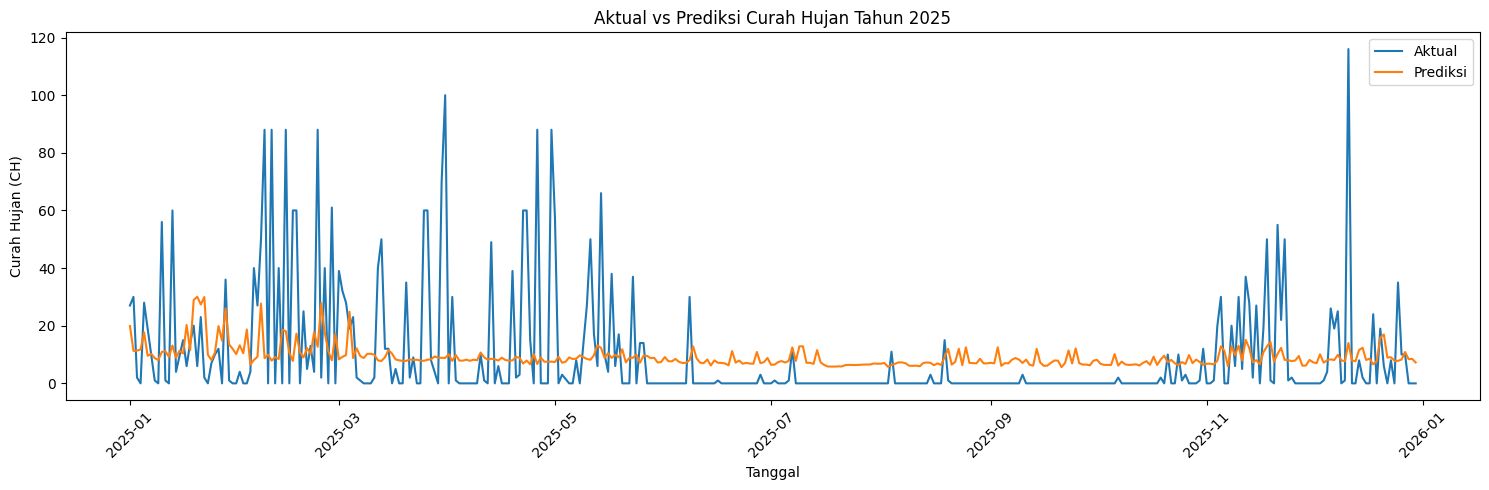

In [55]:
plt.figure(
    figsize=(15, 5)
)

plt.plot(
    hasil_prediksi["Tanggal"],
    hasil_prediksi["Aktual"],
    label="Aktual"
)

plt.plot(
    hasil_prediksi["Tanggal"],
    hasil_prediksi["Prediksi"],
    label="Prediksi"
)

plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (CH)")

plt.title(
    "Aktual vs Prediksi Curah Hujan Tahun 2025"
)

plt.legend()

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

In [56]:
# Cek variabel yang kemungkinan merupakan model
[name for name in globals()
 if "model" in name.lower() or "xgb" in name.lower()]

['XGBRegressor',
 'df_model',
 'xgb_features',
 'train_model',
 'test_model',
 'xgb_final']

In [59]:
# Ambil data tahun 2025
data_2025 = df_model[
    df_model["Tanggal"].dt.year == 2025
].copy()

# Salin data 2025 sebagai data simulasi 2026
data_2026 = data_2025.copy()

# Geser tanggal 2025 menjadi 2026
data_2026["Tanggal"] = data_2026["Tanggal"] + pd.DateOffset(years=1)

# Ambil fitur yang digunakan XGBoost
X_2026 = data_2026[xgb_features].copy()

# Prediksi
pred_2026 = xgb_final.predict(X_2026)

# Hasil prediksi
hasil_prediksi_2026 = pd.DataFrame({
    "Tanggal": data_2026["Tanggal"].values,
    "Prediksi": pred_2026
})

print("HASIL PREDIKSI 2026")
display(hasil_prediksi_2026)

HASIL PREDIKSI 2026


,Tanggal,Prediksi
0,2026-01-01,19.874083
1,2026-01-02,11.253395
2,2026-01-03,11.370782
3,2026-01-04,11.756801
4,2026-01-05,17.656885
...,...,...
358,2026-12-26,8.259650
359,2026-12-27,10.877777
360,2026-12-28,8.398464
361,2026-12-29,8.491862


In [61]:
# EXPORT MODEL UNTUK STREAMLIT

import joblib
from pathlib import Path
from google.colab import files

Path("models").mkdir(exist_ok=True)

# XGBoost TIDAK menggunakan StandardScaler pada pipeline Colab.
model_path = "models/hybrid_xgb.pkl"

joblib.dump(
    xgb_final,
    model_path
)

print("Model XGBoost berhasil disimpan:")
print(model_path)
files.download(model_path)

Model XGBoost berhasil disimpan:
models/hybrid_xgb.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>